# EDA


In [8]:
# setup
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

from warnings import filterwarnings

filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


### Basic checks.


In [3]:
# load data
data = pd.read_csv('ai_jobs_market_2025_2026.csv')
data.head()


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [4]:
# size and columns
data.shape, data.columns.tolist()


((1500, 25),
 ['job_id',
  'job_title',
  'job_category',
  'experience_level',
  'years_of_experience',
  'education_required',
  'annual_salary_usd',
  'salary_min_usd',
  'salary_max_usd',
  'city',
  'country',
  'remote_work',
  'company_size',
  'industry',
  'required_skills',
  'ai_salary_premium_pct',
  'demand_score',
  'demand_growth_yoy_pct',
  'benefits_score_10',
  'posting_year',
  'posting_month',
  'is_senior',
  'is_remote_friendly',
  'is_llm_role',
  'salary_tier'])

In [5]:
# missing values and duplicate rows
data.isna().sum().sort_values(ascending=False), data.duplicated().sum()


(job_id                   0
 job_title                0
 job_category             0
 experience_level         0
 years_of_experience      0
 education_required       0
 annual_salary_usd        0
 salary_min_usd           0
 salary_max_usd           0
 city                     0
 country                  0
 remote_work              0
 company_size             0
 industry                 0
 required_skills          0
 ai_salary_premium_pct    0
 demand_score             0
 demand_growth_yoy_pct    0
 benefits_score_10        0
 posting_year             0
 posting_month            0
 is_senior                0
 is_remote_friendly       0
 is_llm_role              0
 salary_tier              0
 dtype: int64,
 np.int64(0))

In [6]:
# quick look at the main categorical variables
data[['job_category', 'experience_level', 'education_required', 'remote_work', 'company_size', 'industry']].nunique(), data['country'].value_counts().head(10)


(job_category          12
 experience_level       4
 education_required     5
 remote_work            3
 company_size           5
 industry              12
 dtype: int64,
 country
 USA            515
 UK              90
 China           87
 Canada          85
 Global          82
 Germany         81
 Australia       78
 Japan           76
 Switzerland     76
 Netherlands     74
 Name: count, dtype: int64)

In [5]:
# create a few helpful variables
data['log_salary'] = np.log(data['annual_salary_usd'])
data['skills_count'] = data['required_skills'].str.split('|').str.len()

data[['annual_salary_usd', 'log_salary', 'years_of_experience', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'skills_count']].describe().round(2)


,annual_salary_usd,log_salary,years_of_experience,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,skills_count
count,1500.00,1500.00,1500.00,1500.00,1500.00,1500.00,1500.0,1500.00
mean,194892.00,12.12,6.22,10.86,87.52,31.12,7.9,6.37
std,66506.82,0.33,2.68,4.03,8.03,22.05,1.1,1.36
min,90000.00,11.41,1.00,3.00,68.00,5.00,6.0,4.00
25%,144750.00,11.88,4.00,8.20,82.00,15.38,6.9,5.00
50%,180000.00,12.10,6.00,10.50,89.00,23.40,7.9,6.00
75%,236250.00,12.37,8.00,14.20,95.00,42.70,8.9,7.00
max,384000.00,12.86,15.00,18.00,98.00,87.80,9.8,10.00


### Salary distributions.


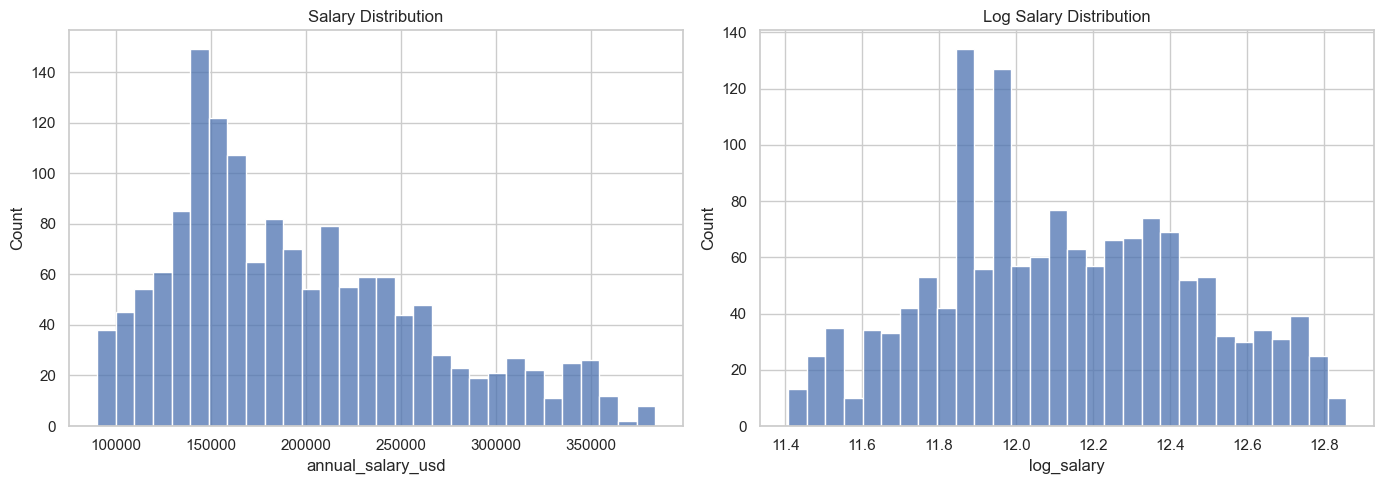

In [6]:
# compare raw salary to log salary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(data=data, x='annual_salary_usd', bins=30, ax=axes[0])
axes[0].set_title('Salary Distribution')
sns.histplot(data=data, x='log_salary', bins=30, ax=axes[1])
axes[1].set_title('Log Salary Distribution')
plt.tight_layout()


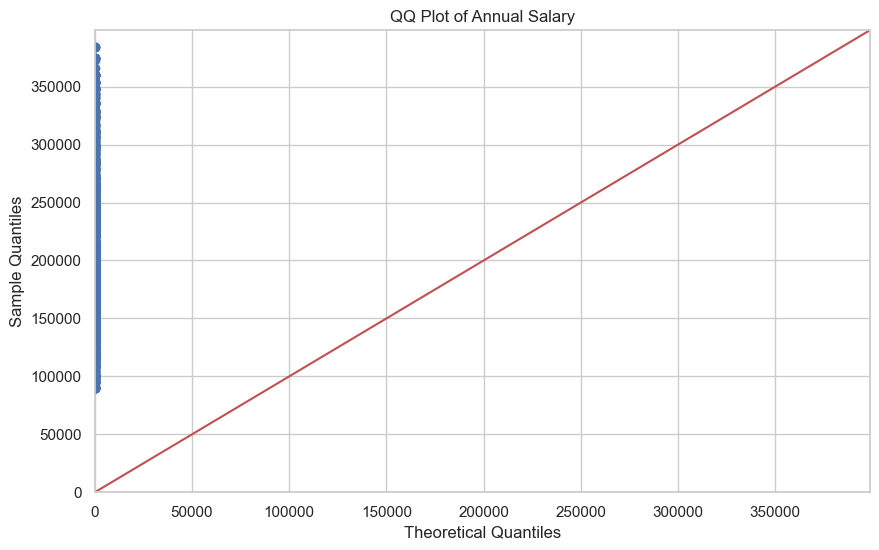

In [14]:
salaryqq = sm.qqplot(data['annual_salary_usd'], line = '45')
plt.title("QQ Plot of Annual Salary")
plt.show()

The QQ plot of annual salary confirms that it is not normally distributed. Some extreme salary values in the right tail at the > $350,000 range are making the data highly right skewed.

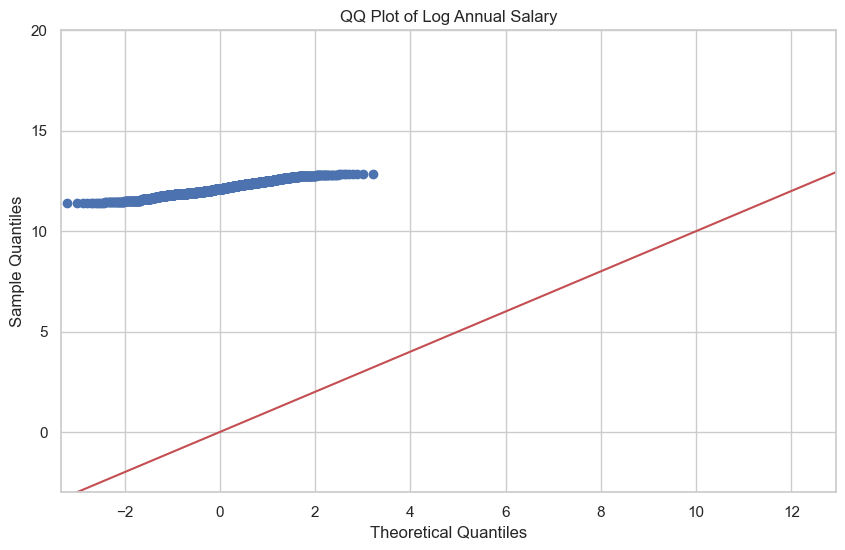

In [16]:
## QQ plot of log transformed salary

sm.qqplot(data['log_salary'], line = '45')
plt.title("QQ Plot of Log Annual Salary")
plt.ylim((-3,20))
plt.show()

Log transforming the data produced more of a normal distribution. The mean is higher than 0, which is why the points fall to the left of the 45 degree line, and the slope is flatter than 1 now, due to lower variance in the log salary than the standard normal distribution. Since using the log of salary makes an improvement for normal distribution, we will use the log version for our linear regression analysis.

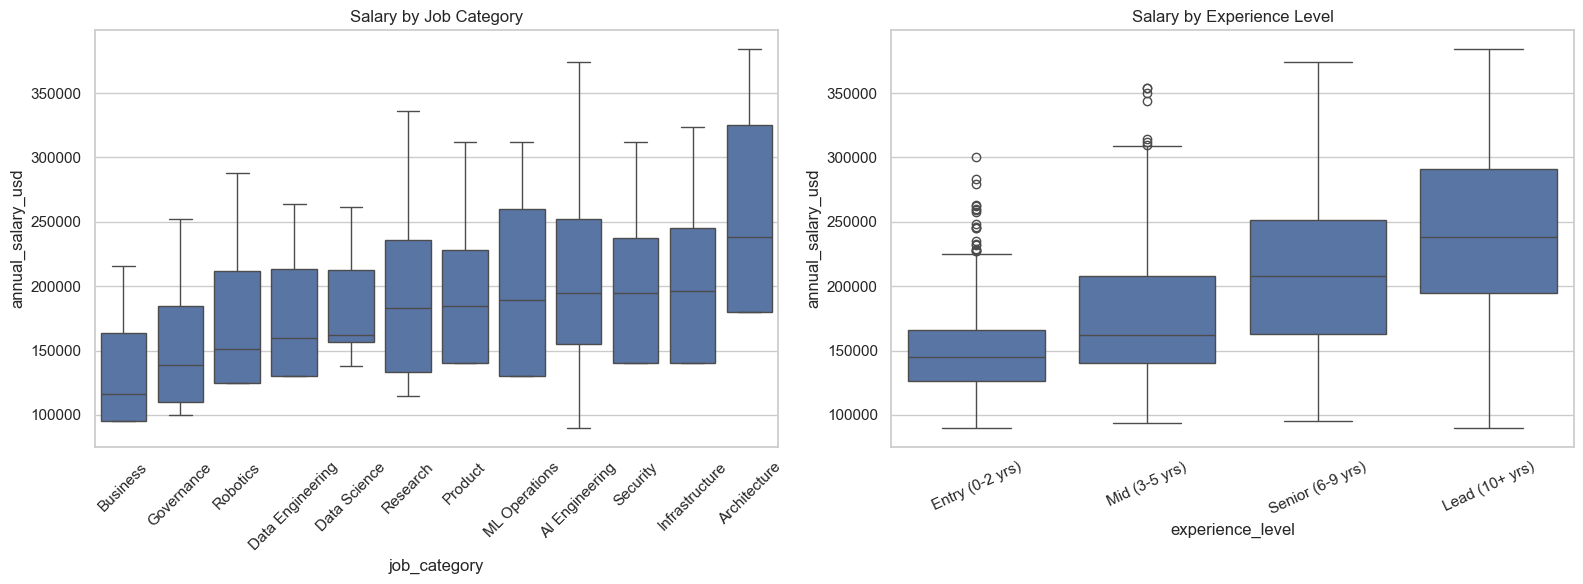

In [9]:
# boxplots for some main group comparisons
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
job_order = data.groupby('job_category')['annual_salary_usd'].median().sort_values().index
exp_order = data.groupby('experience_level')['annual_salary_usd'].median().sort_values().index
sns.boxplot(data=data, x='job_category', y='annual_salary_usd', order=job_order, ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title('Salary by Job Category')
sns.boxplot(data=data, x='experience_level', y='annual_salary_usd', order=exp_order, ax=axes[1])
axes[1].tick_params(axis='x', rotation=25)
axes[1].set_title('Salary by Experience Level')
plt.tight_layout()


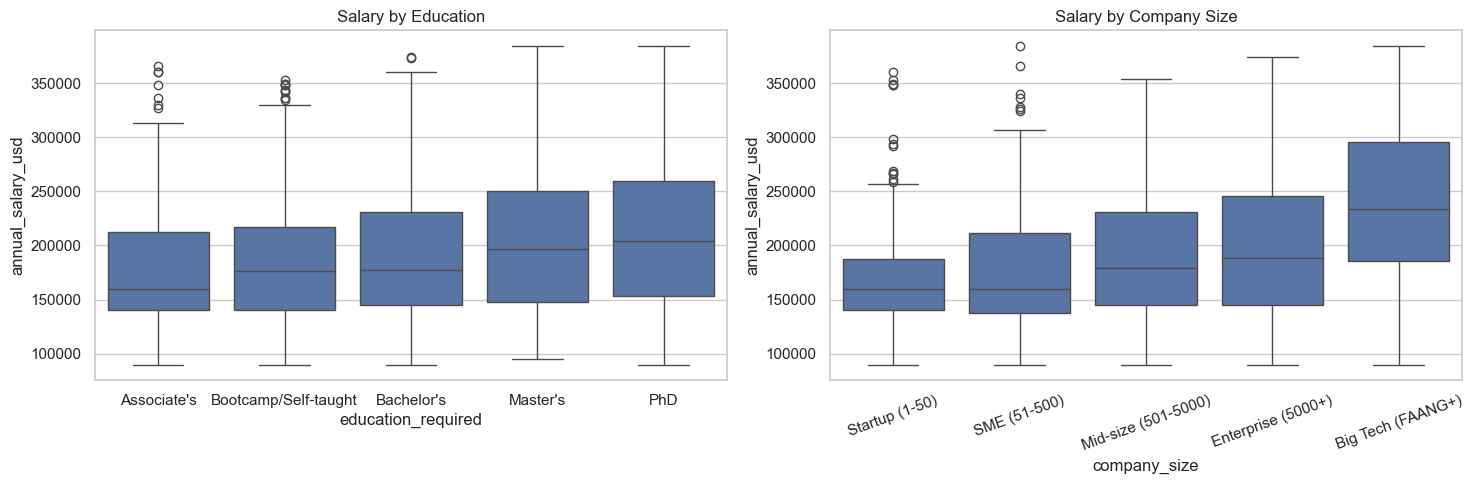

In [10]:
# more salary comparisons
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
edu_order = data.groupby('education_required')['annual_salary_usd'].median().sort_values().index
company_order = data.groupby('company_size')['annual_salary_usd'].median().sort_values().index
sns.boxplot(data=data, x='education_required', y='annual_salary_usd', order=edu_order, ax=axes[0])
axes[0].set_title('Salary by Education')
sns.boxplot(data=data, x='company_size', y='annual_salary_usd', order=company_order, ax=axes[1])
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_title('Salary by Company Size')
plt.tight_layout()


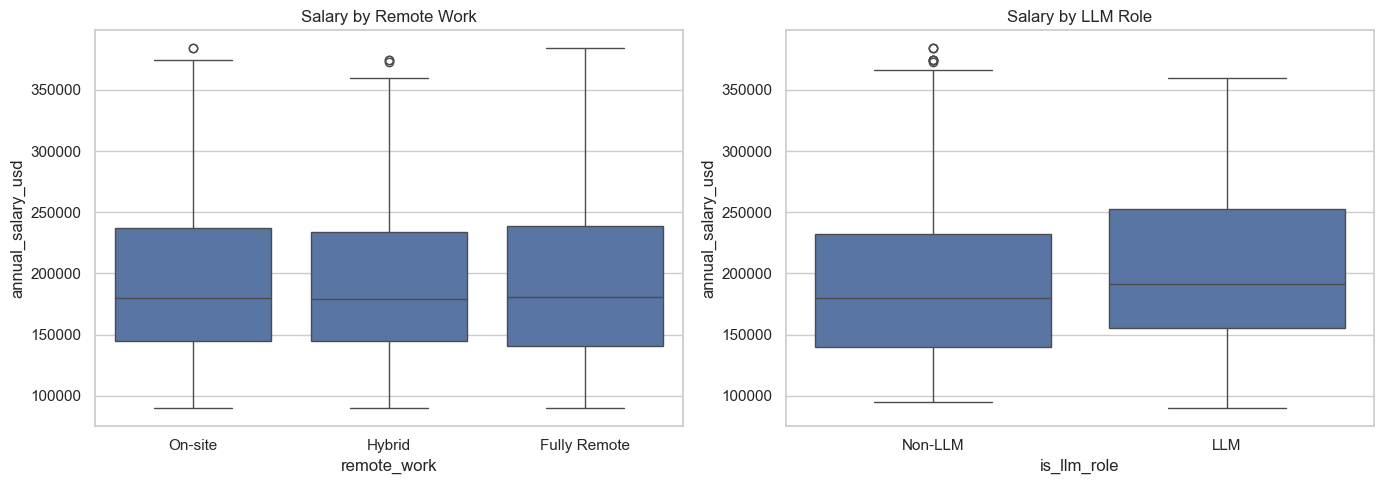

In [11]:
# remote and llm roles
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data, x='remote_work', y='annual_salary_usd', ax=axes[0])
axes[0].set_title('Salary by Remote Work')
sns.boxplot(data=data, x='is_llm_role', y='annual_salary_usd', ax=axes[1])
axes[1].set_title('Salary by LLM Role')
axes[1].set_xticklabels(['Non-LLM', 'LLM'])
plt.tight_layout()


### Grouped summaries.


In [12]:
# average and median salary by category
data.groupby('job_category')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)


,count,mean,median
job_category,,,
Architecture,52,251576.92,238000.0
AI Engineering,736,207982.34,194500.0
Infrastructure,55,203527.27,196000.0
Security,50,200400.00,194500.0
ML Operations,51,199215.69,189000.0
Product,70,194571.43,185000.0
Research,50,192280.00,183000.0
Data Science,127,181275.59,162000.0
Data Engineering,51,176156.86,160000.0


In [13]:
# average and median salary by education
data.groupby('education_required')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)


,count,mean,median
education_required,,,
PhD,280,213252.14,204500.0
Master's,316,205805.70,196500.0
Bachelor's,311,192321.54,177000.0
Bootcamp/Self-taught,297,187002.02,176000.0
Associate's,296,176490.54,160000.0


In [14]:
# average and median salary by remote work
data.groupby('remote_work')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2)


,count,mean,median
remote_work,,,
Fully Remote,445,197967.19,181000.0
On-site,369,195268.83,180000.0
Hybrid,686,192694.46,179000.0


In [15]:
# average and median salary by industry
data.groupby('industry')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2).head(10)


,count,mean,median
industry,,,
Automotive,138,212305.80,210500.0
Consulting,126,199328.57,189000.0
Finance,131,196824.43,185000.0
Healthcare,138,196188.41,180000.0
Retail,131,195360.31,183000.0
Government,136,195029.41,185500.0
Manufacturing,114,194514.04,180000.0
Research,110,193909.09,176500.0
Technology,106,192864.15,175500.0


In [17]:
# average and median salary by country
data.groupby('country')['annual_salary_usd'].agg(['count', 'mean', 'median']).sort_values('mean', ascending=False).round(2).head(10)

,count,mean,median
country,,,
USA,515,226189.90,219000.0
Global,82,222043.90,221000.0
UAE,62,194225.81,186500.0
Switzerland,76,190592.11,167500.0
Australia,78,188000.00,180500.0
France,66,183151.52,160000.0
Singapore,71,181830.99,180000.0
Germany,81,181180.25,173000.0
UK,90,180644.44,167500.0


### Location and ranking views.


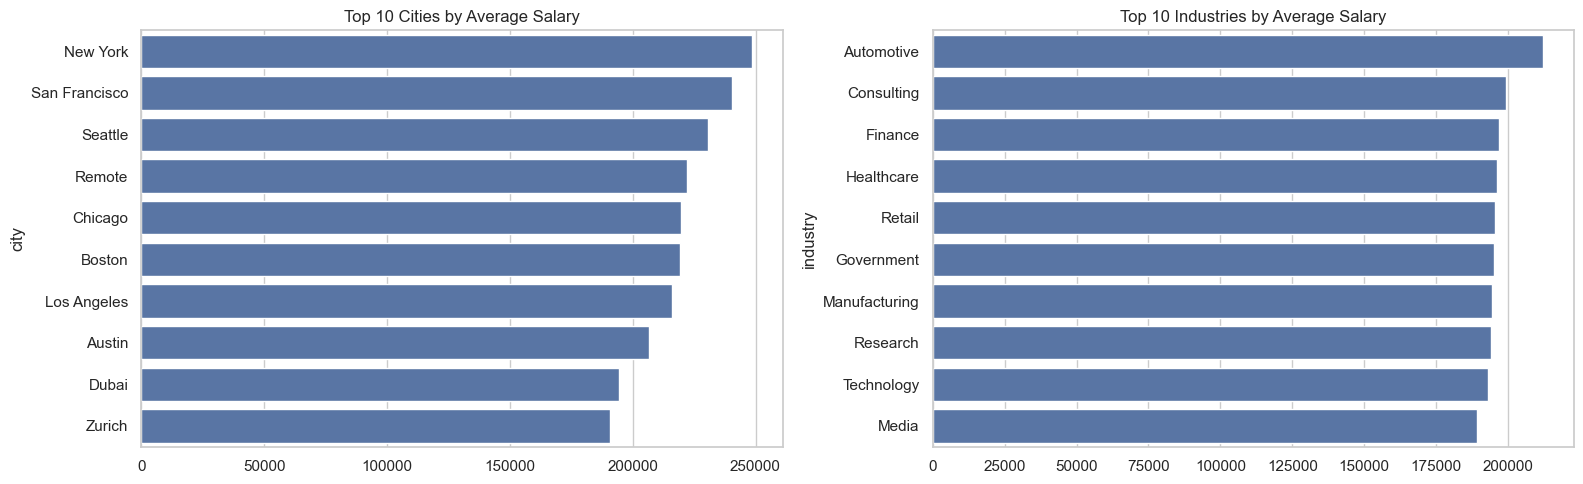

In [16]:
# top cities and industries by average salary
top_cities = data.groupby('city')['annual_salary_usd'].mean().sort_values(ascending=False).head(10)
top_industries = data.groupby('industry')['annual_salary_usd'].mean().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=top_cities.values, y=top_cities.index, ax=axes[0])
axes[0].set_title('Top 10 Cities by Average Salary')
sns.barplot(x=top_industries.values, y=top_industries.index, ax=axes[1])
axes[1].set_title('Top 10 Industries by Average Salary')
plt.tight_layout()


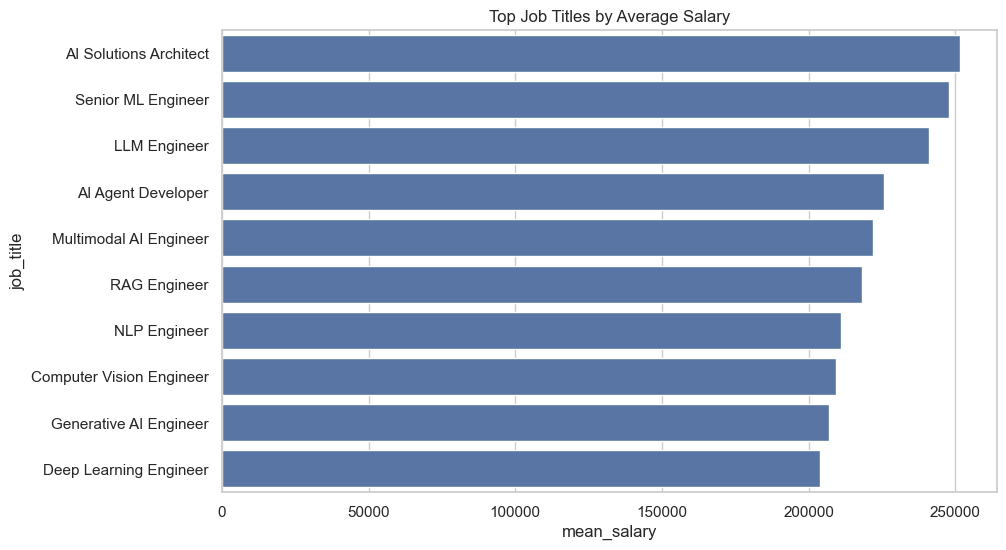

In [17]:
# top job titles with at least 15 postings
top_titles = (
    data.groupby('job_title')
    .agg(count=('annual_salary_usd', 'size'), mean_salary=('annual_salary_usd', 'mean'))
    .query('count >= 15')
    .sort_values('mean_salary', ascending=False)
    .head(10)
)

sns.barplot(data=top_titles.reset_index(), x='mean_salary', y='job_title')
plt.title('Top Job Titles by Average Salary')
plt.show()


### Relationships between variables.


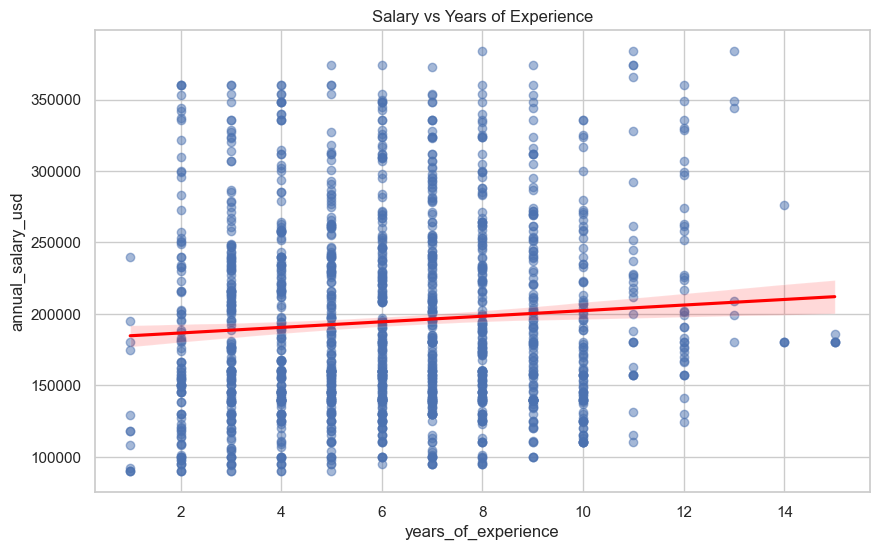

In [18]:
# salary and years of experience
sns.regplot(data=data, x='years_of_experience', y='annual_salary_usd', scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Salary vs Years of Experience')
plt.show()


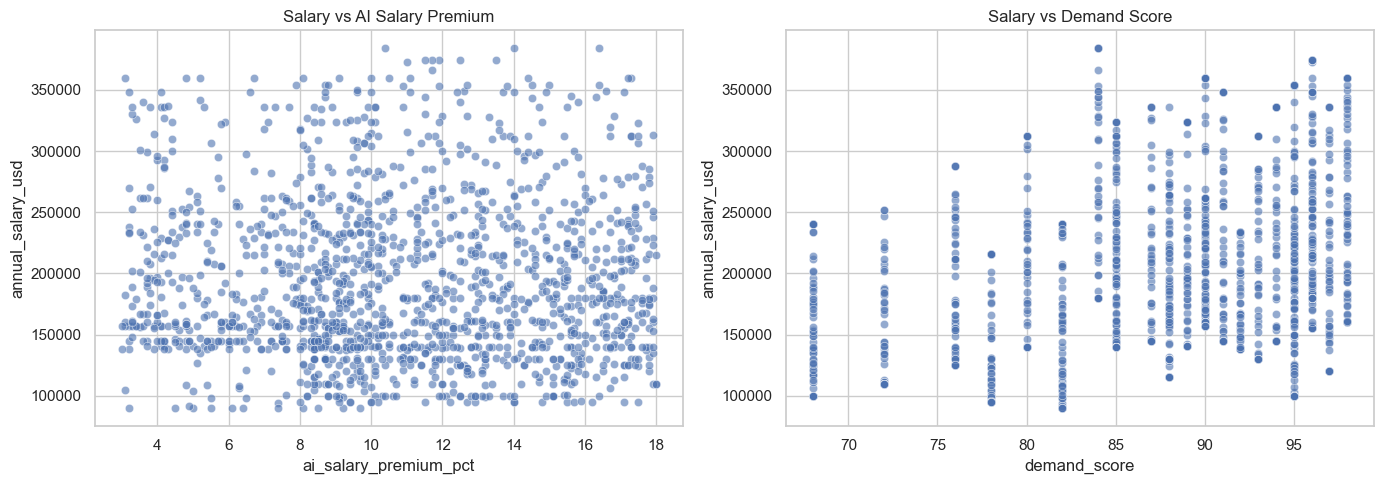

In [19]:
# salary and other numeric measures
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=data, x='ai_salary_premium_pct', y='annual_salary_usd', alpha=0.6, ax=axes[0])
axes[0].set_title('Salary vs AI Salary Premium')
sns.scatterplot(data=data, x='demand_score', y='annual_salary_usd', alpha=0.6, ax=axes[1])
axes[1].set_title('Salary vs Demand Score')
plt.tight_layout()


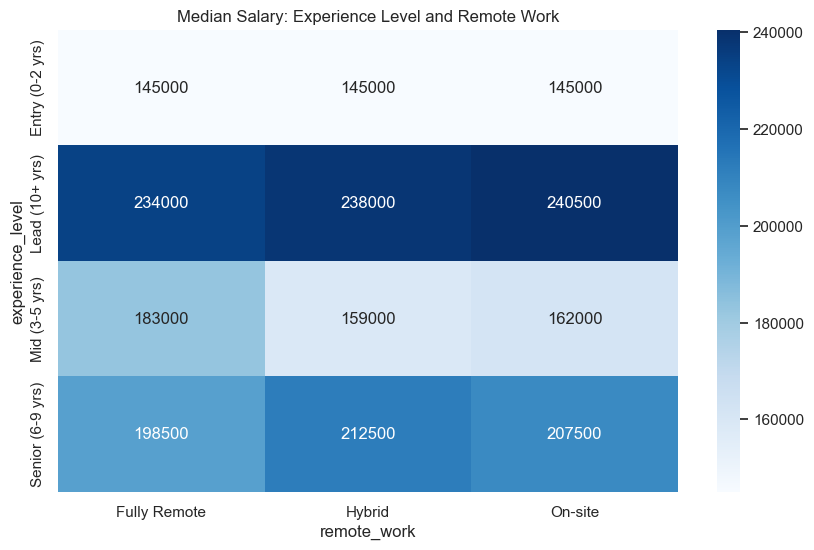

In [20]:
# median salary by experience level and remote work
remote_exp = pd.pivot_table(data, values='annual_salary_usd', index='experience_level', columns='remote_work', aggfunc='median')
sns.heatmap(remote_exp, annot=True, fmt='.0f', cmap='Blues')
plt.title('Median Salary: Experience Level and Remote Work')
plt.show()


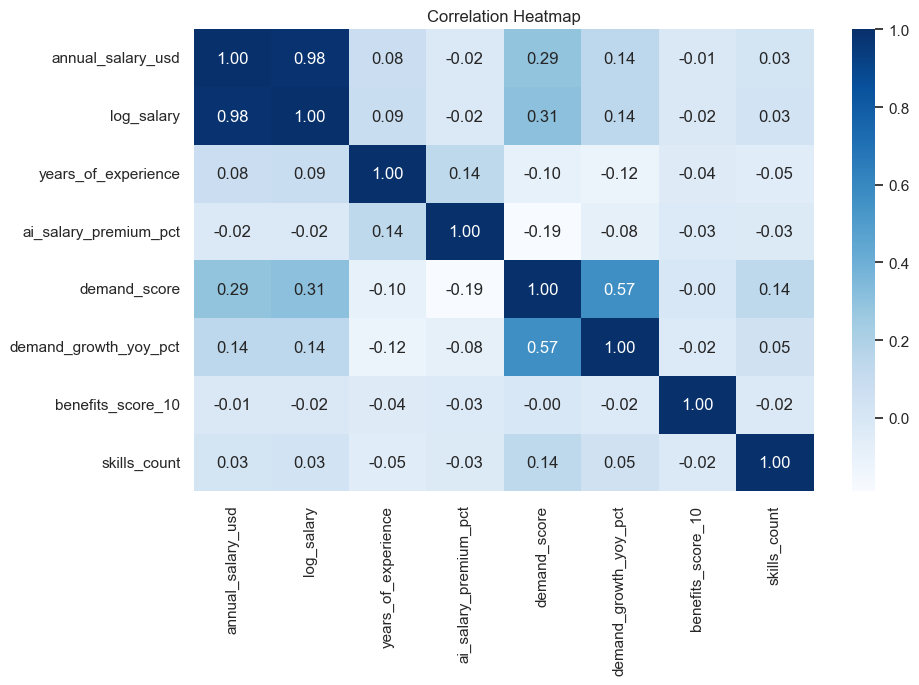

In [21]:
# correlations among numeric variables
corr_cols = ['annual_salary_usd', 'log_salary', 'years_of_experience', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10', 'skills_count']
corr = data[corr_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


## Confirm no missing data

In [22]:
#Confirm no missing data
data.isna().any()

job_id                   False
job_title                False
job_category             False
experience_level         False
years_of_experience      False
education_required       False
annual_salary_usd        False
salary_min_usd           False
salary_max_usd           False
city                     False
country                  False
remote_work              False
company_size             False
industry                 False
required_skills          False
ai_salary_premium_pct    False
demand_score             False
demand_growth_yoy_pct    False
benefits_score_10        False
posting_year             False
posting_month            False
is_senior                False
is_remote_friendly       False
is_llm_role              False
salary_tier              False
log_salary               False
skills_count             False
dtype: bool

## Check for Multicollinearity

In [28]:
# Model with all variables

all_model = smf.ols(data = data, formula = 'annual_salary_usd ~ job_category + experience_level + years_of_experience + education_required + city + country + remote_work + company_size + ai_salary_premium_pct + demand_score + demand_growth_yoy_pct + benefits_score_10 + posting_year + posting_month + is_senior + is_remote_friendly + is_llm_role').fit()
print(all_model.summary())

                            OLS Regression Results                            
Dep. Variable:      annual_salary_usd   R-squared:                       0.803
Model:                            OLS   Adj. R-squared:                  0.796
Method:                 Least Squares   F-statistic:                     115.7
Date:                Sat, 23 May 2026   Prob (F-statistic):               0.00
Time:                        13:03:17   Log-Likelihood:                -17567.
No. Observations:                1500   AIC:                         3.524e+04
Df Residuals:                    1448   BIC:                         3.551e+04
Df Model:                          51                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

In [29]:
#Check for multicollinearity using VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
exog = all_model.model.exog
names = all_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: job_category[T.Architecture]:  1.542
VIF: job_category[T.Business]:  2.073
VIF: job_category[T.Data Engineering]:  1.207
VIF: job_category[T.Data Science]:  1.335
VIF: job_category[T.Governance]:  5.953
VIF: job_category[T.Infrastructure]:  1.352
VIF: job_category[T.ML Operations]:  1.158
VIF: job_category[T.Product]:  1.458
VIF: job_category[T.Research]:  1.224
VIF: job_category[T.Robotics]:  2.704
VIF: job_category[T.Security]:  1.720
VIF: experience_level[T.Lead (10+ yrs)]:  inf
VIF: experience_level[T.Mid (3-5 yrs)]:  1.544
VIF: experience_level[T.Senior (6-9 yrs)]:  inf
VIF: education_required[T.Bachelor's]:  1.669
VIF: education_required[T.Bootcamp/Self-taught]:  1.643
VIF: education_required[T.Master's]:  1.686
VIF: education_required[T.PhD]:  1.618
VIF: city[T.Austin]:  inf
VIF: city[T.Bangalore]:  inf
VIF: city[T.Beijing]:  inf
VIF: city[T.Berlin]:  inf
VIF: city[T.Boston]:  inf
VIF: city[T.Chicago]:  inf
VIF: city[T.Dubai]:  inf
VIF: city[T.London]:  inf
VIF: city[T.Los 

The variables experience_level, city, country, remote_work, is_senior, and is_remote_friendly have VIFs of infinity. This suggests that experience_level and is_senior are correlated with each other, city and country are correlated with each other, and is_remote_friendly and remote_work are correlated with each other.

To address multicollinearity for our multivariable linear model:
- We will use only city and not country. 
- We will not include is_senior, as it is a dummy variable serving as a duplicate of the senior category of the experience_level variable.
- We will use remote_work and not use remote_friendly, since remote_friendly is a binary version of remote_work encoding Hybrid/Remote vs in person.

Confirm that VIF drops when removing variables with multicollinearity.

In [35]:
#removed is_senior (kept experience_level and years_of_experience)
#removed is_remote_friendly
#removed country
new_covars = ['job_category','experience_level','years_of_experience', 
'education_required', 'city' , 'remote_work' , 'company_size',
'ai_salary_premium_pct' ,'demand_score','demand_growth_yoy_pct' ,
'benefits_score_10', 'posting_year','posting_month','is_llm_role']

new_formula = f'annual_salary_usd ~ {" + ".join(new_covars)}'
new_model = smf.ols(data = data, formula = new_formula).fit()


exog = new_model.model.exog
names = new_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: job_category[T.Architecture]:  1.542
VIF: job_category[T.Business]:  2.073
VIF: job_category[T.Data Engineering]:  1.207
VIF: job_category[T.Data Science]:  1.335
VIF: job_category[T.Governance]:  5.953
VIF: job_category[T.Infrastructure]:  1.352
VIF: job_category[T.ML Operations]:  1.158
VIF: job_category[T.Product]:  1.458
VIF: job_category[T.Research]:  1.224
VIF: job_category[T.Robotics]:  2.704
VIF: job_category[T.Security]:  1.720
VIF: experience_level[T.Lead (10+ yrs)]:  1.555
VIF: experience_level[T.Mid (3-5 yrs)]:  1.544
VIF: experience_level[T.Senior (6-9 yrs)]:  1.522
VIF: education_required[T.Bachelor's]:  1.669
VIF: education_required[T.Bootcamp/Self-taught]:  1.643
VIF: education_required[T.Master's]:  1.686
VIF: education_required[T.PhD]:  1.618
VIF: city[T.Austin]:  1.968
VIF: city[T.Bangalore]:  1.750
VIF: city[T.Beijing]:  2.073
VIF: city[T.Berlin]:  2.024
VIF: city[T.Boston]:  1.875
VIF: city[T.Chicago]:  1.984
VIF: city[T.Dubai]:  1.791
VIF: city[T.London]:  2.

With the correlated variables removed, none of the VIFs of the remaining variables are high. 